In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models

กำลังเริ่มโหลดรูปภาพ...
กำลังโหลด Class 10...
กำลังโหลด Class 11...
กำลังโหลด Class 12...
กำลังโหลด Class 13...
กำลังโหลด Class 14...
กำลังโหลด Class 15...
โหลดข้อมูลสำเร็จ! ทั้งหมด 431 รูป

--- ⚡ เริ่มเทรน Fold ที่ 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
Accuracy ของ Fold 1: 81.61%

--- ⚡ เริ่มเทรน Fold ที่ 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
Accuracy ของ Fold 2: 86.05%

--- ⚡ เริ่มเทรน Fold ที่ 3 ---


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step
Accuracy ของ Fold 3: 88.37%

--- ⚡ เริ่มเทรน Fold ที่ 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step
Accuracy ของ Fold 4: 81.40%

--- ⚡ เริ่มเทรน Fold ที่ 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
Accuracy ของ Fold 5: 83.72%

📊 รายงานประสิทธิภาพล่าสุด
              precision    recall  f1-score   support

          10       0.79      0.79      0.79        14
          11       0.85      0.79      0.81        14
          12       0.82      1.00      0.90        14
          13       0.94      0.94      0.94        16
          14       0.77      0.71      0.74        14
          15       0.85      0.79      0.81        14

    accuracy                           0.84        86
   macro avg       0.83      0.83      0.83        86
weighted avg       0.84      0.84      0.84        86



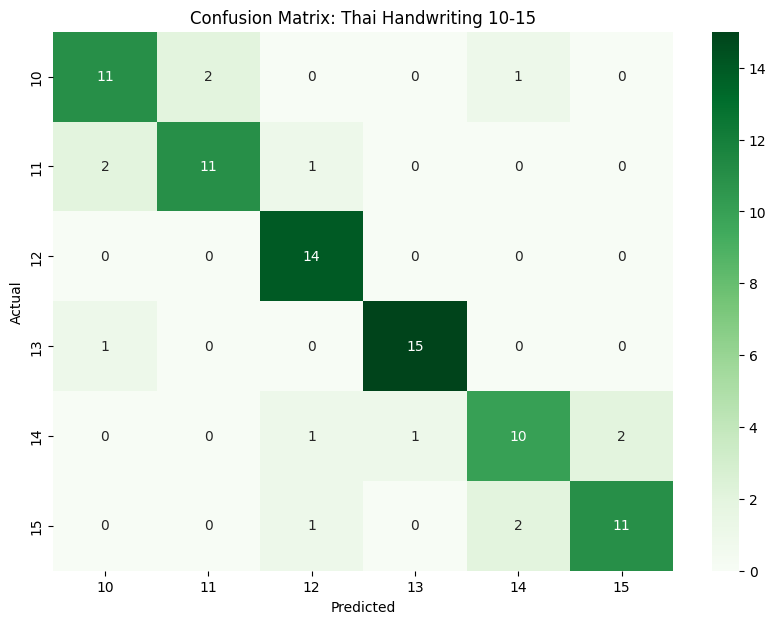

In [8]:
# --- กำหนด Path ของโฟลเดอร์ข้อมูล ---
# ให้เปลี่ยน 'ชื่อโฟลเดอร์ของคุณ' เป็นชื่อโฟลเดอร์จริงๆ ที่อยู่ใน Drive
# แนะนำ: คลิกขวาที่โฟลเดอร์ในแถบซ้ายมือของ Colab แล้วเลือก "Copy path" มาวาง
DATA_PATH = '/content/drive/MyDrive/Dataset'

FOLDERS = [str(i) for i in range(10, 16)] # รายชื่อโฟลเดอร์ย่อย 10, 11, 12, 13, 14, 15
IMG_SIZE = 64 # ขนาดภาพที่จะส่งเข้าโมเดล

# --- ฟังก์ชันโหลดรูปภาพจากโฟลเดอร์โดยตรง ---
def load_images_from_folders(base_path):
    images = [] # สำหรับเก็บพิกเซลรูปภาพ
    labels = [] # สำหรับเก็บเลขคลาส (0-5)

    print("กำลังเริ่มโหลดรูปภาพ...")
    for label, folder in enumerate(FOLDERS):
        path = os.path.join(base_path, folder)

        # ตรวจสอบว่ามีโฟลเดอร์นี้อยู่จริงไหม
        if not os.path.exists(path):
            print(f"⚠️ ไม่พบโฟลเดอร์: {path} (ข้าม...)")
            continue

        print(f"กำลังโหลด Class {folder}...")
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                # อ่านไฟล์ภาพแบบ Grayscale (ขาวดำ)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # ถ้าอ่านไฟล์สำเร็จ (ไม่เป็น None)
                if img is not None:
                    # ปรับขนาดภาพให้เท่ากันทุกรูป
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    images.append(img)
                    labels.append(label)
            except Exception as e:
                # กรณีไฟล์เสียหรือมีปัญหาให้ข้ามไป
                continue

    return np.array(images), np.array(labels)

# เรียกใช้ฟังก์ชันเพื่อดึงข้อมูลจาก Drive
X, y = load_images_from_folders(DATA_PATH)

# ตรวจสอบว่าโหลดข้อมูลมาได้หรือไม่
if len(X) == 0:
    print("❌ ไม่พบข้อมูลรูปภาพ! โปรดตรวจสอบ Path และชื่อโฟลเดอร์อีกครั้ง")
else:
    # เตรียมข้อมูลก่อนเทรน (Data Preprocessing)
    # ปรับรูปร่างข้อมูลให้เข้ากับ CNN (จำนวนภาพ, กว้าง, ยาว, 1 ช่องสี)
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    # ทำ Scaling ค่าพิกเซล (Normalize) จาก 0-255 ให้เป็น 0-1
    X = X.astype('float32') / 255.0
    print(f"โหลดข้อมูลสำเร็จ! ทั้งหมด {len(X)} รูป")

    # --- ฟังก์ชันสร้างโมเดล CNN ---
    def build_model():
        model = models.Sequential([
            # Layer แรกดึงจุดเด่นของภาพ
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
            layers.MaxPooling2D((2, 2)),

            # Layer สองดึงความซับซ้อนของลายเส้นตัวเลขไทย
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.MaxPooling2D((2, 2)),

            # แปลงเป็นเส้นตรงเข้าสู่ Neural Network ปกติ
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5), # ป้องกันการจำข้อมูลแบบท่องจำ (Overfitting)
            layers.Dense(len(FOLDERS), activation='softmax') # ทำนาย 6 คลาส
        ])

        model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    # --- Cross Validation (5-Fold) ---
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n--- ⚡ เริ่มเทรน Fold ที่ {fold+1} ---")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = build_model()

        # ฝึกสอนโมเดล (ปรับ epochs ตามความเหมาะสม)
        model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

        # ทำนายผลเพื่อวัดประสิทธิภาพ
        y_pred_probs = model.predict(X_val)
        y_pred = np.argmax(y_pred_probs, axis=1)

        acc = accuracy_score(y_val, y_pred)
        print(f"Accuracy ของ Fold {fold+1}: {acc*100:.2f}%")

    # --- สรุปผลและ Confusion Matrix (รอบสุดท้าย) ---
    print("\n" + "="*30)
    print("📊 รายงานประสิทธิภาพล่าสุด")
    print("="*30)
    print(classification_report(y_val, y_pred, target_names=FOLDERS))

    # วาดรูป Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=FOLDERS, yticklabels=FOLDERS)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: Thai Handwriting 10-15')
    plt.show()

In [9]:
# เซฟโมเดลหลังจากเทรนเสร็จ
model.save('thai_number_model.keras')